In [1]:
import matplotlib.pyplot as plt
from difmap_wrapper import DifmapSession

# Fichier et sélection 
DATA_PATH      = "tests/test_data/0003-066_X.SPLIT.1"  # chemin vers le fichier FITS
REQUESTED_POL  = "RR"                                   # polarisation : 'RR', 'LL', 'RL', 'LR'
REQUESTED_IFS  = (1, 0)                                # (premier_IF, dernier_IF) ; 0 = jusqu'au dernier

#  Imagerie
MAP_SIZE       = 512    # taille de la grille en pixels
CELL_SIZE_MAS  = 0.1    # résolution par pixel en millisecondes d'arc

# Fonctions utilitaires 
def format_if_range(ifs):
    """Convertit (1, 2) → '1..2', (1, 0) → 'tous'."""
    a, b = ifs
    return "tous" if b == 0 else f"{a}..{b}"

def unique_ifs(data):
    """Retourne la liste triée des numéros d'IFs présents et lus dans les données."""
    import numpy as np
    return sorted(set(int(x) for x in np.unique(data["if_no"])))


## 1. Ouvrir la session et charger les données


In [2]:
# Création de la session — singleton : une seule instance active à la fois.
# Le fichier est chargé une seule fois.
# Toutes les cellules suivantes réutilisent la même session sans recharger les données.
session = DifmapSession()
session.observe(DATA_PATH)                                              # lit le fichier UV/FITS
selected_pol = session.obs.select(pol=REQUESTED_POL, ifs=REQUESTED_IFS) # choisit pol + IFs

print(f"Source      : {session.obs.source}")
print(f"Polarisation: {selected_pol}")
print(f"IFs selectionnés : {format_if_range(REQUESTED_IFS)}")


Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1      1.6e+07
 03        3  8.81372e+09      1.6e+07          1      1.6e+07
 

## 2. Informations de la sélection


In [3]:
# Résumé des visibilités chargées : IFs effectifs, nombre de points, amplitude moyenne.
data = session.obs.get_data()   # dict numpy : u, v, amp, phase, if_no …

print(f"IFs demandés          : {format_if_range(REQUESTED_IFS)}")
print(f"IFs effectivement lus : {unique_ifs(data)}")
print(f"Nombre de visibilites : {len(data['u'])}")
print(f"Amplitude moyenne (Jy): {data['amp'].mean():.4f}")


IFs demandés          : tous
IFs effectivement lus : [1, 2, 3, 4]
Nombre de visibilites : 13072
Amplitude moyenne (Jy): 2.8165


## 3. Generer le plan UV

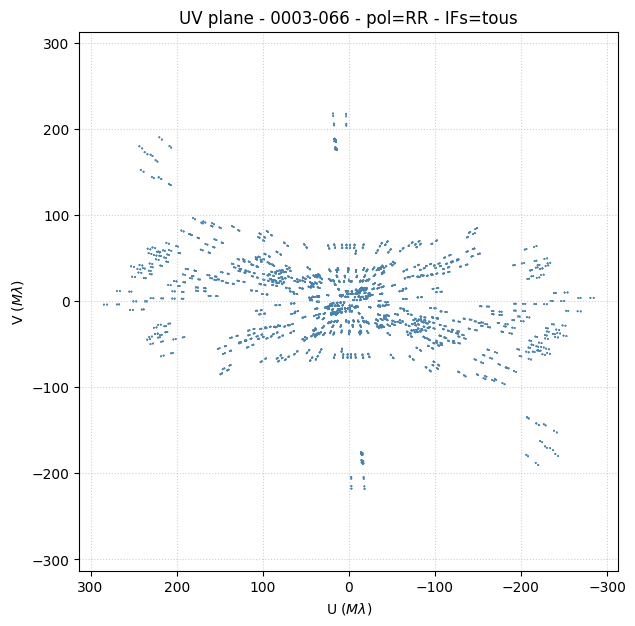

In [4]:
# Couverture UV en Mλ. Les points conjugués (-U, -V) sont ajoutés automatiquement.
session.vis.uvplot(
    figsize=(7, 7),
    color="steelblue",
    s=1.5,
    alpha=0.35,
    title=f"UV plane - {session.obs.source} - pol={selected_pol} - IFs={format_if_range(REQUESTED_IFS)}"
)
plt.show()


## 4. Radplot 

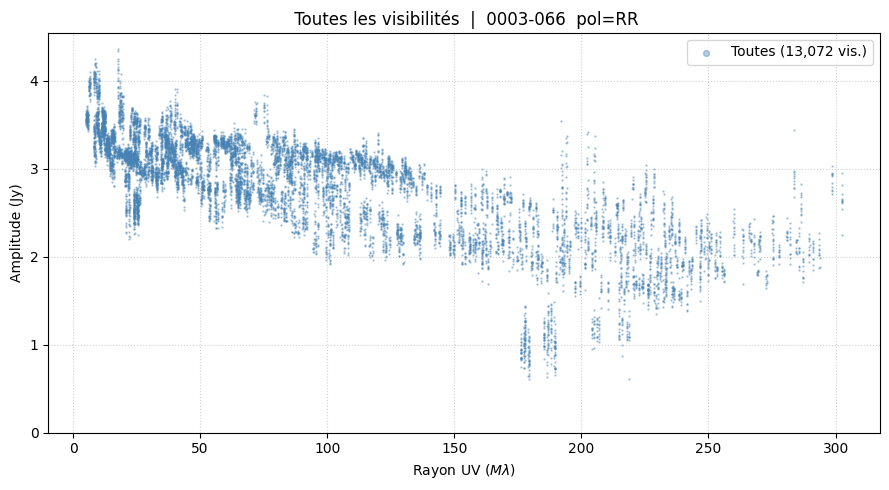

In [5]:
import numpy as np

# ── Étape 1 / 3 : toutes les visibilités ─────────────────────────────────────
data = session.obs.get_data()
u, v = data['u'], data['v']
amp  = data['amp']
uv_r = np.sqrt(u**2 + v**2) / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(uv_r, amp, s=0.5, color='steelblue', alpha=0.4,
           label=f"Toutes ({len(amp):,} vis.)")
ax.set_xlabel(r"Rayon UV ($M\lambda$)")
ax.set_ylabel("Amplitude (Jy)")
ax.set_ylim(bottom=0)
ax.set_title(f" Toutes les visibilités  |  {session.obs.source}  pol={selected_pol}")
ax.legend(markerscale=6)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Construire une dirty map

Inverting map and beam 
Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.


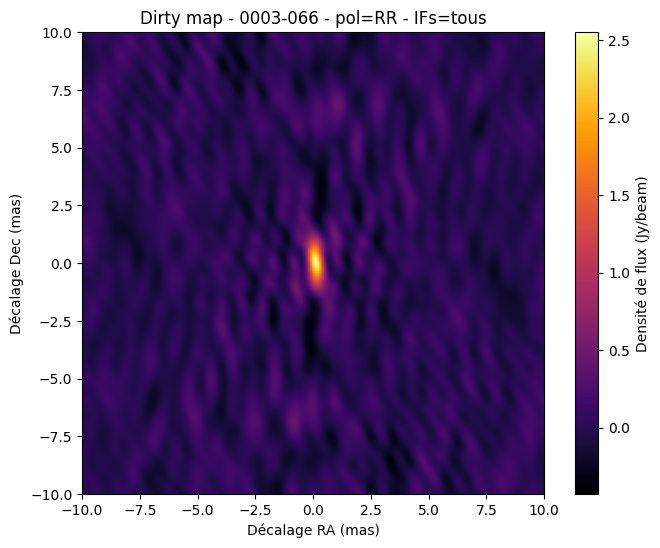

In [6]:
# Dirty map : TF inverse des visibilités sans déconvolution.
# Image brute avant CLEAN
session.imager.mapsize(MAP_SIZE, CELL_SIZE_MAS)        # grille : pixels × mas/pixel
session.imager.invert()                                # calcule la TF inverse

session.vis.mapplot(
    title=f"Dirty map - {session.obs.source} - pol={selected_pol} - IFs={format_if_range(REQUESTED_IFS)}",
    cmap="inferno" ,  # palette : 'inferno', 'viridis', 'gray' …
    xlim=(-10, 10),   # bornes RA en mas
    ylim=(-10, 10),   # bornes Dec en mas
)
plt.show()


## 6. Libèrer la session à la fin


In [7]:
session.cleanup()
